[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
<ipython-input-2-db79c4c26bf2>:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  posts.loc[:, 'clean_content'] = posts['content'].astype(str).apply(clean_text)



=== Summary Statistics for Posts ===
          compound                                 profanity_count            \
              mean       std     min     max count            mean       std   
platform                                                                       
4chan    -0.140187  0.509969 -0.9897  0.9153    31        0.129032  0.427546   

                        
         min max count  
platform                
4chan      0   2    31  

=== Summary Statistics for Comments ===
          compound                                  profanity_count            \
              mean       std     min     max  count            mean       std   
platform                                                                        
4chan    -0.096835  0.480066 -0.9984  0.9944   1570        0.152866  0.501948   
Reddit   -0.069251  0.505242 -0.9988  0.9983  49184        0.089013  0.335508   

                         
         min max  count  
platform                 
4chan      0   7

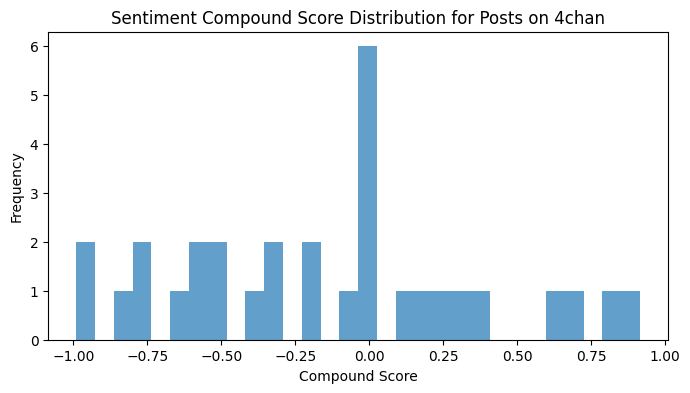

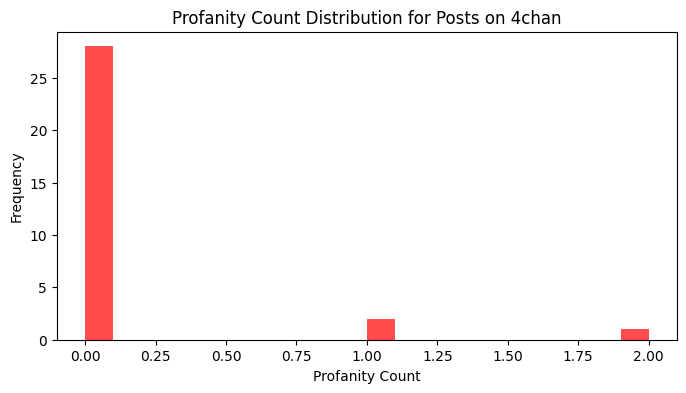

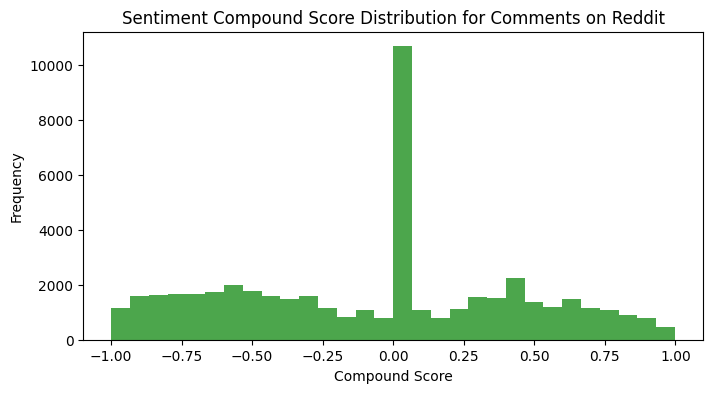

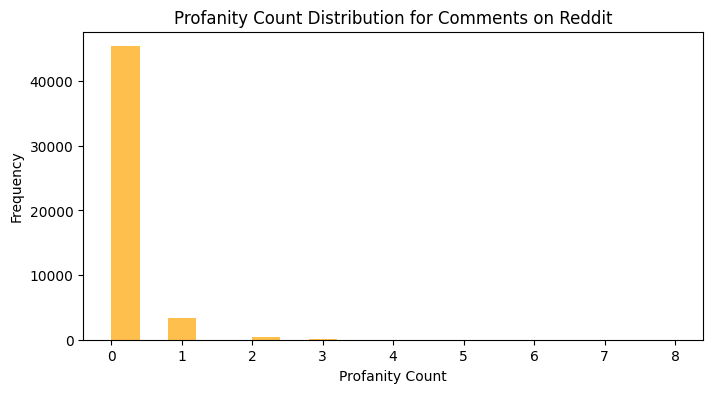

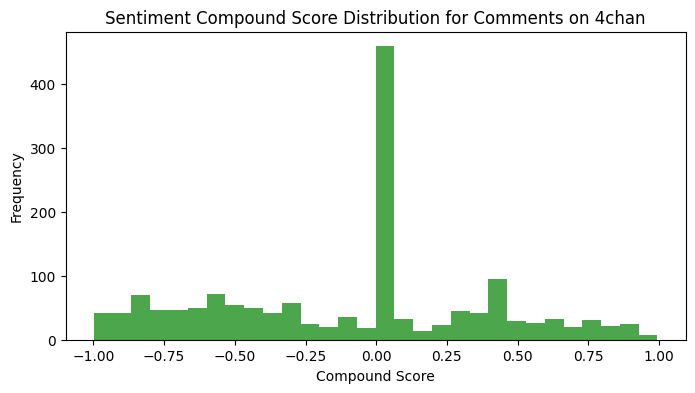

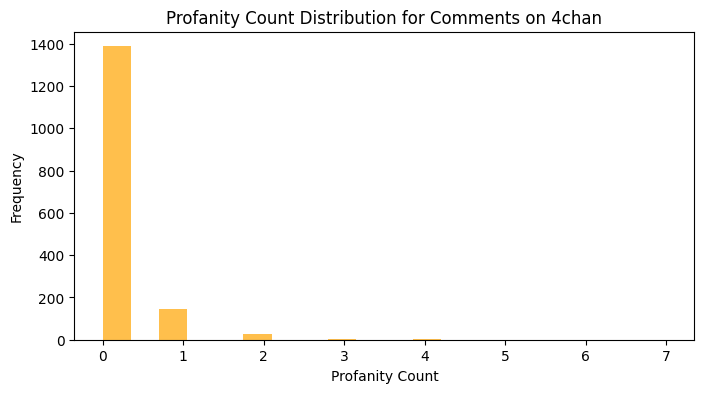

In [2]:
#Trump Dataset
import pandas as pd
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup
import warnings
from bs4 import MarkupResemblesLocatorWarning

# Suppress warnings from BeautifulSoup
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# -----------------------------
# 1. Define a Text Cleaning Function
# -----------------------------
def clean_text(text):
    text = str(text)
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove punctuation and non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------------
# 2. Define a Custom List of Profanity Words
# -----------------------------
custom_profanity = set([
    "fuck", "shit", "bitch", "asshole", "damn", "crap",
    "dick", "piss", "cunt", "fucker", "bastard"
])

def count_profanity(text):
    words = text.split()
    return sum(1 for word in words if word in custom_profanity)

# -----------------------------
# 3. Load the Datasets
# -----------------------------
# Update these file paths as needed.
posts = pd.read_csv('trump_posts_20250218_010823.csv')
comments = pd.read_csv('trump_comments_20250218_010823.csv')

# -----------------------------
# 4. Filter for the 'trump' Topic (if applicable)
# -----------------------------
if 'topic' in posts.columns:
    posts = posts[posts['topic'].str.lower() == 'trump']
if 'topic' in comments.columns:
    comments = comments[comments['topic'].str.lower() == 'trump']

# -----------------------------
# 5. Clean the Text Data
# -----------------------------
posts.loc[:, 'clean_content'] = posts['content'].astype(str).apply(clean_text)
comments.loc[:, 'clean_text'] = comments['comment_text'].astype(str).apply(clean_text)

# -----------------------------
# 6. Sentiment Analysis using VADER
# -----------------------------
sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sid.polarity_scores(text)

posts.loc[:, 'sentiment'] = posts['clean_content'].apply(get_sentiment)
posts.loc[:, 'compound'] = posts['sentiment'].apply(lambda x: x['compound'])

comments.loc[:, 'sentiment'] = comments['clean_text'].apply(get_sentiment)
comments.loc[:, 'compound'] = comments['sentiment'].apply(lambda x: x['compound'])

# -----------------------------
# 7. Profanity Analysis
# -----------------------------
posts.loc[:, 'profanity_count'] = posts['clean_content'].apply(count_profanity)
comments.loc[:, 'profanity_count'] = comments['clean_text'].apply(count_profanity)

# -----------------------------
# 8. Print Summary Statistics
# -----------------------------
print("\n=== Summary Statistics for Posts ===")
print(posts.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

print("\n=== Summary Statistics for Comments ===")
print(comments.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

# -----------------------------
# 9. Visualization by Platform
# -----------------------------
# For Posts
for platform in posts['platform'].unique():
    subset = posts[posts['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7)
        plt.title(f'Sentiment Compound Score Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='red')
        plt.title(f'Profanity Count Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()

# For Comments
for platform in comments['platform'].unique():
    subset = comments[comments['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7, color='green')
        plt.title(f'Sentiment Compound Score Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='orange')
        plt.title(f'Profanity Count Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



=== Summary Statistics for Posts ===
Empty DataFrame
Columns: [(compound, mean), (compound, std), (compound, min), (compound, max), (compound, count), (profanity_count, mean), (profanity_count, std), (profanity_count, min), (profanity_count, max), (profanity_count, count)]
Index: []

=== Summary Statistics for Comments ===
          compound                                  profanity_count            \
              mean       std     min     max  count            mean       std   
platform                                                                        
4chan    -0.106594  0.547470 -0.9944  0.9910    821        0.148599  0.447038   
Reddit   -0.026793  0.511659 -0.9998  0.9991  41030        0.072703  0.299248   

                         
         min max  count  
platform                 
4chan      0   4    821  
Reddit     0   7  41030  


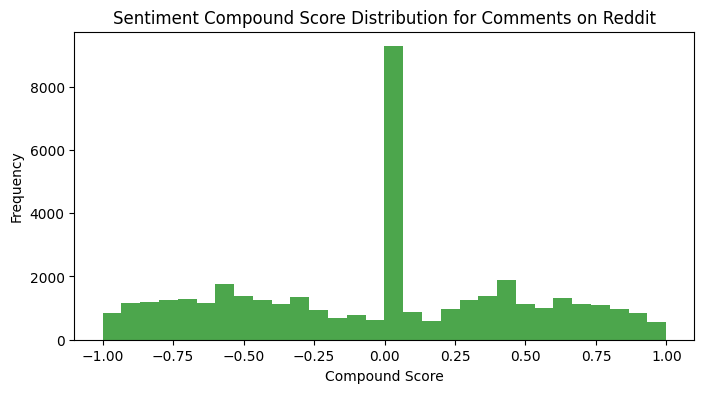

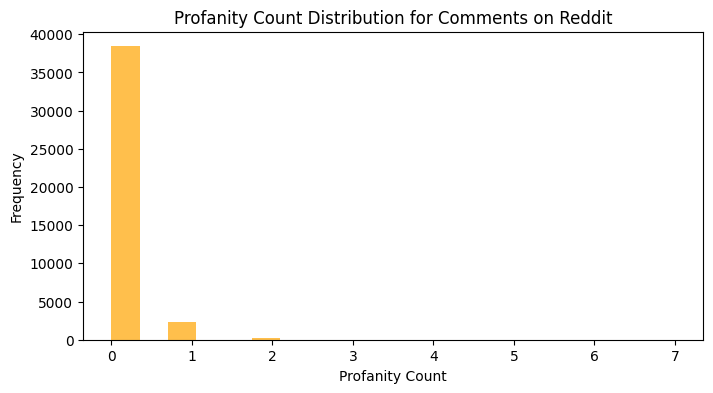

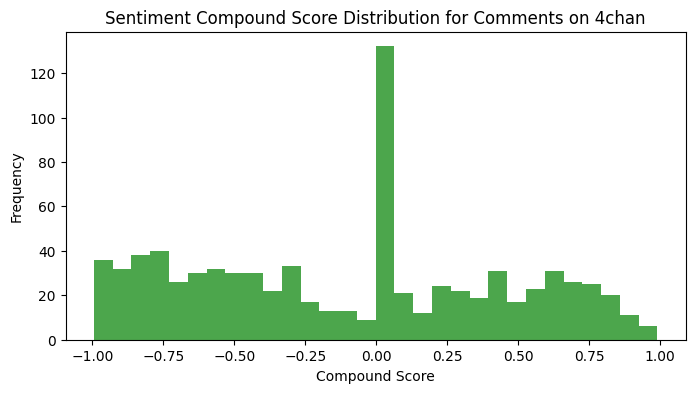

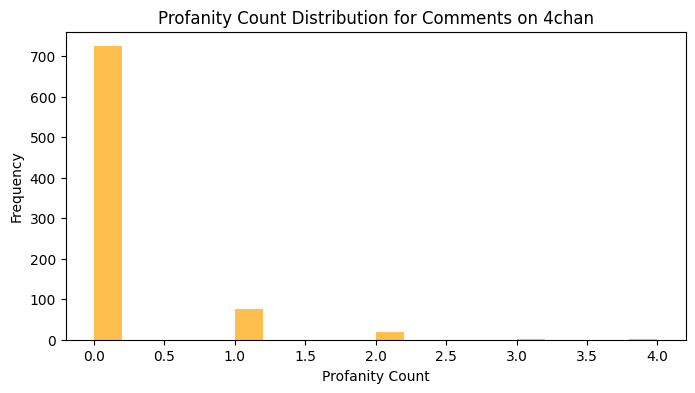

In [3]:
# Heatlh Dataset

import pandas as pd
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup
import warnings
from bs4 import MarkupResemblesLocatorWarning

# Suppress warnings from BeautifulSoup
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# -----------------------------
# 1. Define a Text Cleaning Function
# -----------------------------
def clean_text(text):
    text = str(text)
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove punctuation and non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------------
# 2. Define a Custom List of Profanity Words
# -----------------------------
custom_profanity = set([
    "fuck", "shit", "bitch", "asshole", "damn", "crap",
    "dick", "piss", "cunt", "fucker", "bastard"
])

def count_profanity(text):
    words = text.split()
    return sum(1 for word in words if word in custom_profanity)

# -----------------------------
# 3. Load the Datasets
# -----------------------------
# Update these file paths as needed.
posts = pd.read_csv('health_posts_20250222_165338.csv')
comments = pd.read_csv('health_comments_20250222_165338.csv')

# -----------------------------
# 4. Filter for the 'trump' Topic (if applicable)
# -----------------------------
if 'topic' in posts.columns:
    posts = posts[posts['topic'].str.lower() == 'trump']
if 'topic' in comments.columns:
    comments = comments[comments['topic'].str.lower() == 'trump']

# -----------------------------
# 5. Clean the Text Data
# -----------------------------
posts.loc[:, 'clean_content'] = posts['content'].astype(str).apply(clean_text)
comments.loc[:, 'clean_text'] = comments['comment_text'].astype(str).apply(clean_text)

# -----------------------------
# 6. Sentiment Analysis using VADER
# -----------------------------
sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sid.polarity_scores(text)

posts.loc[:, 'sentiment'] = posts['clean_content'].apply(get_sentiment)
posts.loc[:, 'compound'] = posts['sentiment'].apply(lambda x: x['compound'])

comments.loc[:, 'sentiment'] = comments['clean_text'].apply(get_sentiment)
comments.loc[:, 'compound'] = comments['sentiment'].apply(lambda x: x['compound'])

# -----------------------------
# 7. Profanity Analysis
# -----------------------------
posts.loc[:, 'profanity_count'] = posts['clean_content'].apply(count_profanity)
comments.loc[:, 'profanity_count'] = comments['clean_text'].apply(count_profanity)

# -----------------------------
# 8. Print Summary Statistics
# -----------------------------
print("\n=== Summary Statistics for Posts ===")
print(posts.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

print("\n=== Summary Statistics for Comments ===")
print(comments.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

# -----------------------------
# 9. Visualization by Platform
# -----------------------------
# For Posts
for platform in posts['platform'].unique():
    subset = posts[posts['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7)
        plt.title(f'Sentiment Compound Score Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='red')
        plt.title(f'Profanity Count Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()

# For Comments
for platform in comments['platform'].unique():
    subset = comments[comments['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7, color='green')
        plt.title(f'Sentiment Compound Score Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='orange')
        plt.title(f'Profanity Count Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



=== Summary Statistics for Posts ===
Empty DataFrame
Columns: [(compound, mean), (compound, std), (compound, min), (compound, max), (compound, count), (profanity_count, mean), (profanity_count, std), (profanity_count, min), (profanity_count, max), (profanity_count, count)]
Index: []

=== Summary Statistics for Comments ===
          compound                                  profanity_count            \
              mean       std     min     max  count            mean       std   
platform                                                                        
4chan    -0.088206  0.491873 -0.9980  0.9951  14525        0.112151  0.389753   
Reddit   -0.021638  0.488022 -0.9983  0.9998  21424        0.072022  0.308424   

                         
         min max  count  
platform                 
4chan      0   7  14525  
Reddit     0  11  21424  


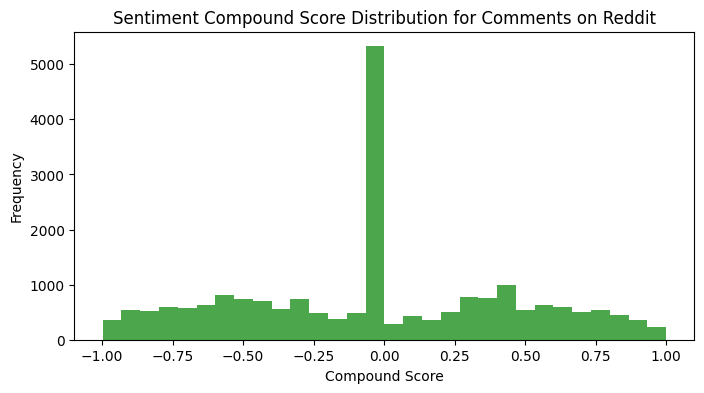

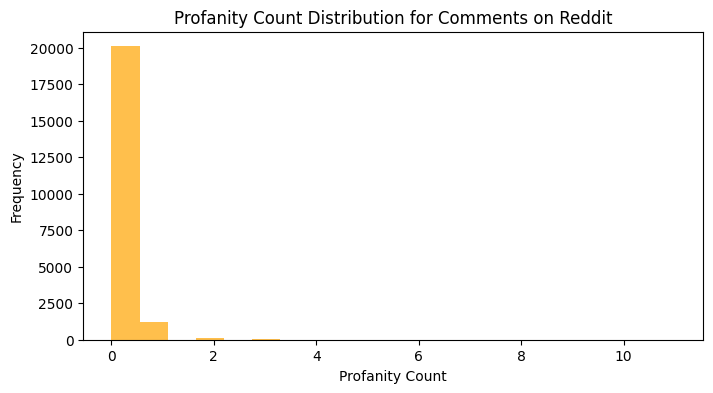

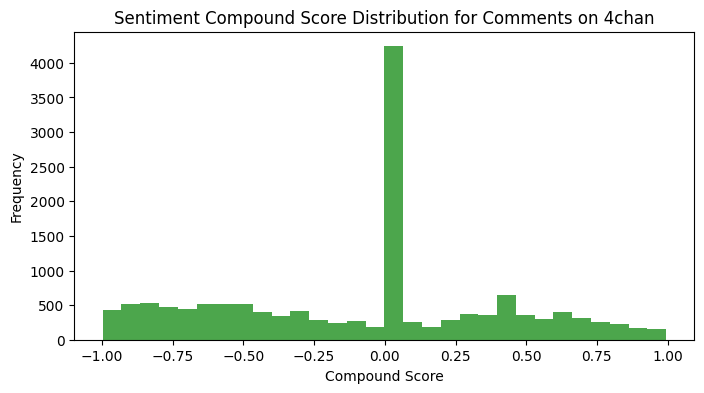

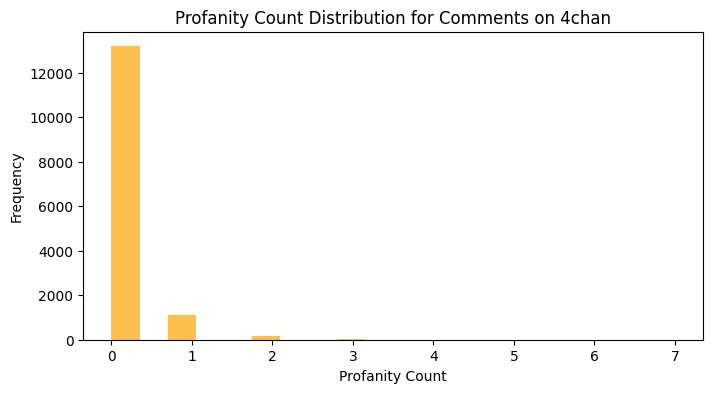

In [6]:
# AI Dataset
import pandas as pd
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup
import warnings
from bs4 import MarkupResemblesLocatorWarning

# Suppress warnings from BeautifulSoup
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# -----------------------------
# 1. Define a Text Cleaning Function
# -----------------------------
def clean_text(text):
    text = str(text)
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove punctuation and non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------------
# 2. Define a Custom List of Profanity Words
# -----------------------------
custom_profanity = set([
    "fuck", "shit", "bitch", "asshole", "damn", "crap",
    "dick", "piss", "cunt", "fucker", "bastard"
])

def count_profanity(text):
    words = text.split()
    return sum(1 for word in words if word in custom_profanity)

# -----------------------------
# 3. Load the Datasets
# -----------------------------
# Update these file paths as needed.
posts = pd.read_csv('AI_posts_20250222_160224.csv')
comments = pd.read_csv('AI_comments_20250222_160224.csv')

# -----------------------------
# 4. Filter for the 'trump' Topic (if applicable)
# -----------------------------
if 'topic' in posts.columns:
    posts = posts[posts['topic'].str.lower() == 'trump']
if 'topic' in comments.columns:
    comments = comments[comments['topic'].str.lower() == 'trump']

# -----------------------------
# 5. Clean the Text Data
# -----------------------------
posts.loc[:, 'clean_content'] = posts['content'].astype(str).apply(clean_text)
comments.loc[:, 'clean_text'] = comments['comment_text'].astype(str).apply(clean_text)

# -----------------------------
# 6. Sentiment Analysis using VADER
# -----------------------------
sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sid.polarity_scores(text)

posts.loc[:, 'sentiment'] = posts['clean_content'].apply(get_sentiment)
posts.loc[:, 'compound'] = posts['sentiment'].apply(lambda x: x['compound'])

comments.loc[:, 'sentiment'] = comments['clean_text'].apply(get_sentiment)
comments.loc[:, 'compound'] = comments['sentiment'].apply(lambda x: x['compound'])

# -----------------------------
# 7. Profanity Analysis
# -----------------------------
posts.loc[:, 'profanity_count'] = posts['clean_content'].apply(count_profanity)
comments.loc[:, 'profanity_count'] = comments['clean_text'].apply(count_profanity)

# -----------------------------
# 8. Print Summary Statistics
# -----------------------------
print("\n=== Summary Statistics for Posts ===")
print(posts.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

print("\n=== Summary Statistics for Comments ===")
print(comments.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

# -----------------------------
# 9. Visualization by Platform
# -----------------------------
# For Posts
for platform in posts['platform'].unique():
    subset = posts[posts['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7)
        plt.title(f'Sentiment Compound Score Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='red')
        plt.title(f'Profanity Count Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()

# For Comments
for platform in comments['platform'].unique():
    subset = comments[comments['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7, color='green')
        plt.title(f'Sentiment Compound Score Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='orange')
        plt.title(f'Profanity Count Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



=== Summary Statistics for Posts ===
Empty DataFrame
Columns: [(compound, mean), (compound, std), (compound, min), (compound, max), (compound, count), (profanity_count, mean), (profanity_count, std), (profanity_count, min), (profanity_count, max), (profanity_count, count)]
Index: []

=== Summary Statistics for Comments ===
          compound                                  profanity_count            \
              mean       std     min     max  count            mean       std   
platform                                                                        
4chan    -0.002659  0.555427 -0.9937  0.9852    491        0.140530  0.467960   
Reddit    0.014633  0.502821 -0.9992  0.9998  43059        0.081632  0.319089   

                         
         min max  count  
platform                 
4chan      0   3    491  
Reddit     0   8  43059  


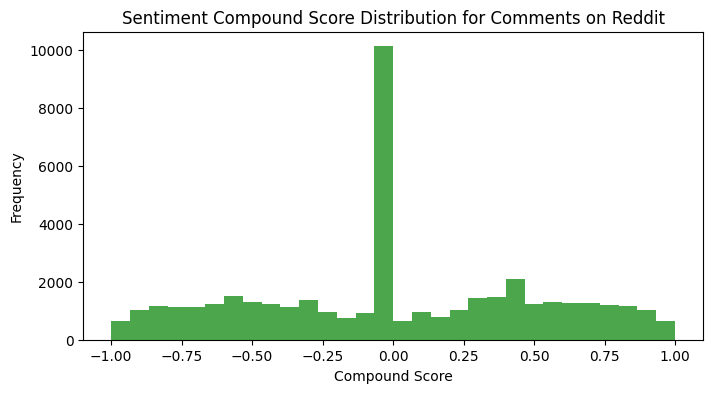

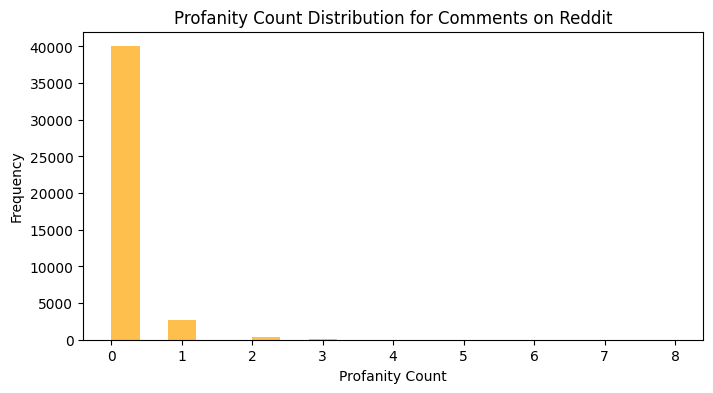

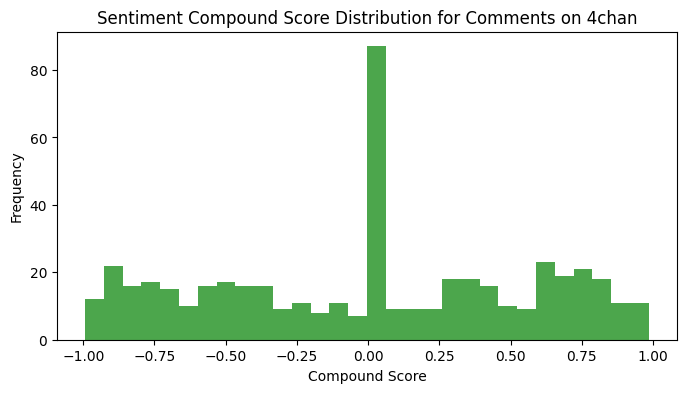

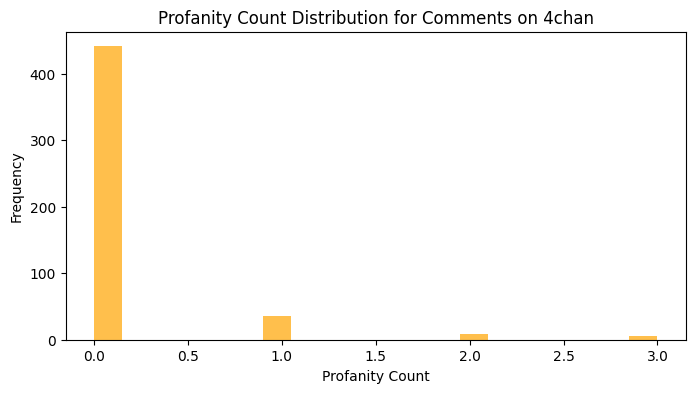

In [7]:
# Climate Dataset
import pandas as pd
import matplotlib.pyplot as plt
import re
from bs4 import BeautifulSoup
import warnings
from bs4 import MarkupResemblesLocatorWarning

# Suppress warnings from BeautifulSoup
warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# -----------------------------
# 1. Define a Text Cleaning Function
# -----------------------------
def clean_text(text):
    text = str(text)
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove punctuation and non-alphanumeric characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------------
# 2. Define a Custom List of Profanity Words
# -----------------------------
custom_profanity = set([
    "fuck", "shit", "bitch", "asshole", "damn", "crap",
    "dick", "piss", "cunt", "fucker", "bastard"
])

def count_profanity(text):
    words = text.split()
    return sum(1 for word in words if word in custom_profanity)

# -----------------------------
# 3. Load the Datasets
# -----------------------------
# Update these file paths as needed.
posts = pd.read_csv('climate_posts_20250222_164358.csv')
comments = pd.read_csv('climate_comments_20250222_164358.csv')

# -----------------------------
# 4. Filter for the 'trump' Topic (if applicable)
# -----------------------------
if 'topic' in posts.columns:
    posts = posts[posts['topic'].str.lower() == 'trump']
if 'topic' in comments.columns:
    comments = comments[comments['topic'].str.lower() == 'trump']

# -----------------------------
# 5. Clean the Text Data
# -----------------------------
posts.loc[:, 'clean_content'] = posts['content'].astype(str).apply(clean_text)
comments.loc[:, 'clean_text'] = comments['comment_text'].astype(str).apply(clean_text)

# -----------------------------
# 6. Sentiment Analysis using VADER
# -----------------------------
sid = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sid.polarity_scores(text)

posts.loc[:, 'sentiment'] = posts['clean_content'].apply(get_sentiment)
posts.loc[:, 'compound'] = posts['sentiment'].apply(lambda x: x['compound'])

comments.loc[:, 'sentiment'] = comments['clean_text'].apply(get_sentiment)
comments.loc[:, 'compound'] = comments['sentiment'].apply(lambda x: x['compound'])

# -----------------------------
# 7. Profanity Analysis
# -----------------------------
posts.loc[:, 'profanity_count'] = posts['clean_content'].apply(count_profanity)
comments.loc[:, 'profanity_count'] = comments['clean_text'].apply(count_profanity)

# -----------------------------
# 8. Print Summary Statistics
# -----------------------------
print("\n=== Summary Statistics for Posts ===")
print(posts.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

print("\n=== Summary Statistics for Comments ===")
print(comments.groupby('platform')[['compound', 'profanity_count']].agg(['mean','std','min','max','count']))

# -----------------------------
# 9. Visualization by Platform
# -----------------------------
# For Posts
for platform in posts['platform'].unique():
    subset = posts[posts['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7)
        plt.title(f'Sentiment Compound Score Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Posts
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='red')
        plt.title(f'Profanity Count Distribution for Posts on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()

# For Comments
for platform in comments['platform'].unique():
    subset = comments[comments['platform'].str.lower() == platform.lower()]
    if not subset.empty:
        # Sentiment Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['compound'], bins=30, alpha=0.7, color='green')
        plt.title(f'Sentiment Compound Score Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Compound Score')
        plt.ylabel('Frequency')
        plt.show()

        # Profanity Count Distribution for Comments
        plt.figure(figsize=(8, 4))
        plt.hist(subset['profanity_count'], bins=20, alpha=0.7, color='orange')
        plt.title(f'Profanity Count Distribution for Comments on {platform.capitalize()}')
        plt.xlabel('Profanity Count')
        plt.ylabel('Frequency')
        plt.show()
